In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import pairwise_distances
import seaborn as sns

# optional for nicer visuals
sns.set(style="whitegrid")

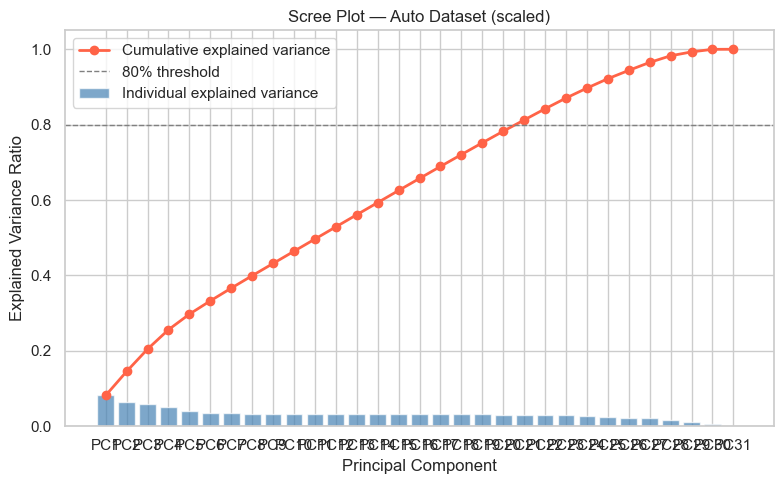

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv("../data/raw/train_values.csv")
df = df.reset_index(drop=True)

# Scale the numerical features
scaler = StandardScaler()
X = df.select_dtypes(include=['number']).values
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)

evr = pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

# print('Explained variance ratio per component:', np.round(evr, 3))
# print('Cumulative explained variance:         ', np.round(cumulative, 3))

# Plot the explained variance ratio
n_components = len(evr)
x_pos = np.arange(1, n_components + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x_pos, evr, color='steelblue', alpha=0.7, label='Individual explained variance')
ax.plot(x_pos, cumulative, 'o-', color='tomato', linewidth=2, label='Cumulative explained variance')
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80% threshold')

ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title('Scree Plot — Auto Dataset (scaled)', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(['PC' + str(i) for i in x_pos])
ax.legend()
plt.tight_layout()
plt.show()


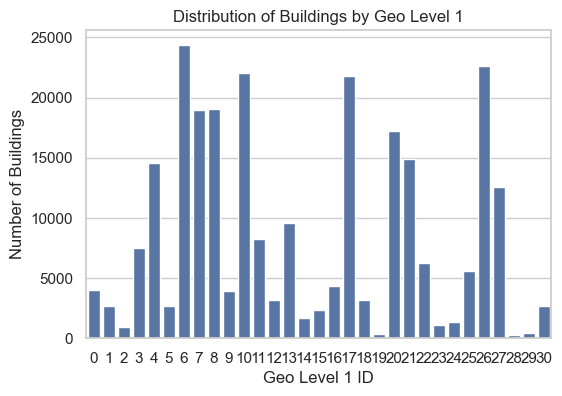

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="geo_level_1_id", data=df)
plt.title("Distribution of Buildings by Geo Level 1")
plt.xlabel("Geo Level 1 ID")
plt.ylabel("Number of Buildings")
plt.show()

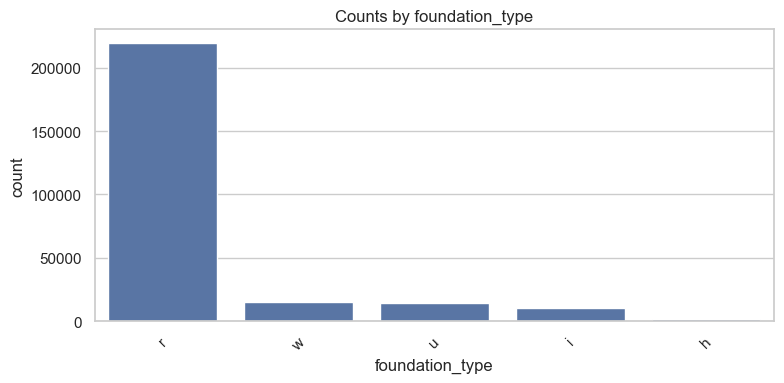

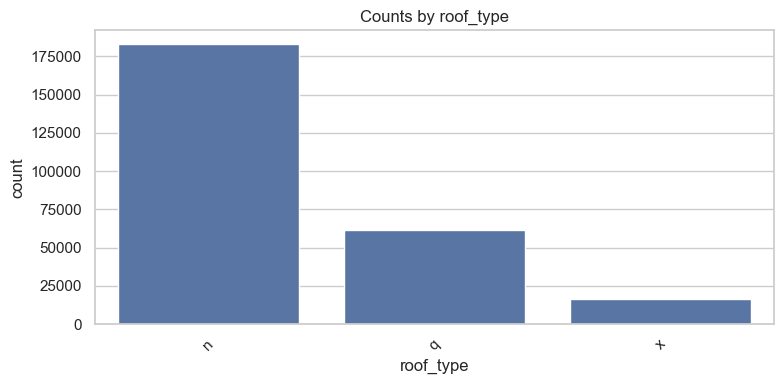

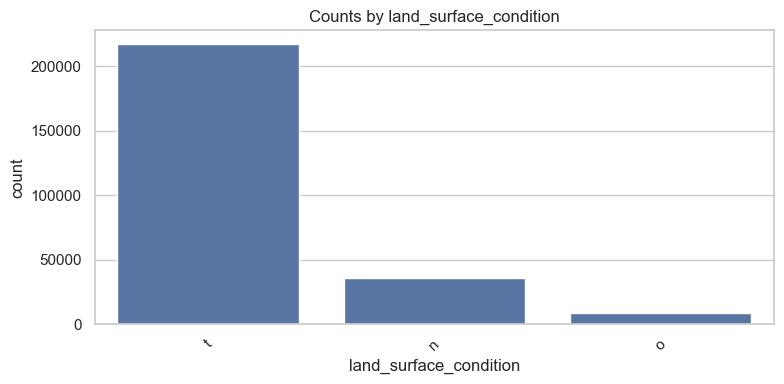

In [9]:
categorical_cols = ["foundation_type", "roof_type", "land_surface_condition"]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Counts by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<Axes: title={'center': 'Number of Buildings with Each Damage Grade'}, xlabel='damage_grade'>

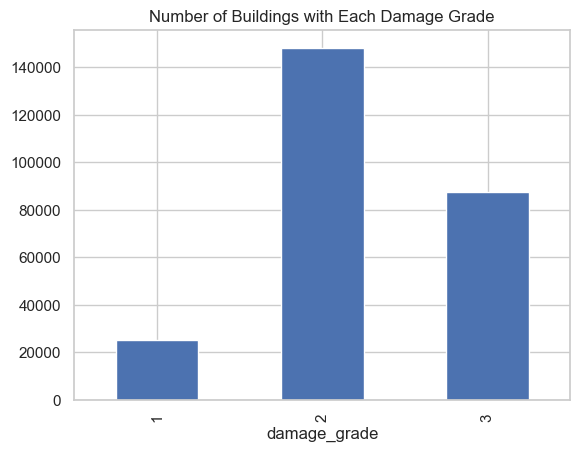

In [15]:


train_values = pd.read_csv("../data/raw/train_values.csv", index_col="building_id")
train_labels = pd.read_csv("../data/raw/train_labels.csv", index_col="building_id")

(
    train_labels.damage_grade.value_counts()
    .sort_index()
    .plot.bar(title="Number of Buildings with Each Damage Grade")
)

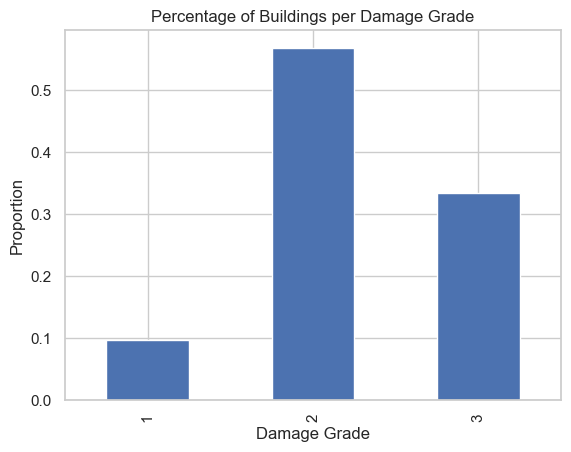

damage_grade
1     9.640792
2    56.891186
3    33.468022
Name: proportion, dtype: float64


In [20]:
damage_percent = (
    train_labels.damage_grade.value_counts(normalize=True)
    .sort_index()
)

plt.figure()
damage_percent.plot(kind="bar")
plt.title("Percentage of Buildings per Damage Grade")
plt.xlabel("Damage Grade")
plt.ylabel("Proportion")
plt.show()

damage_percent = (
    train_labels.damage_grade.value_counts(normalize=True)
    .sort_index()
)

print(damage_percent * 100)

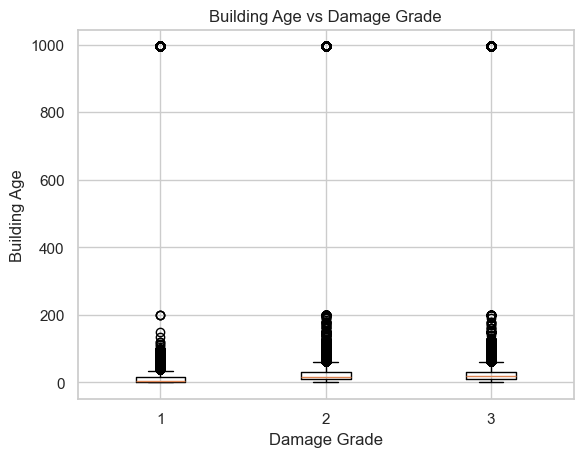

In [17]:
import matplotlib.pyplot as plt

data = train_values.join(train_labels)

plt.figure()
plt.boxplot(
    [data[data.damage_grade == i]["age"] for i in [1, 2, 3]],
    tick_labels=[1, 2, 3]
)
plt.title("Building Age vs Damage Grade")
plt.xlabel("Damage Grade")
plt.ylabel("Building Age")
plt.show()

<Figure size 640x480 with 0 Axes>

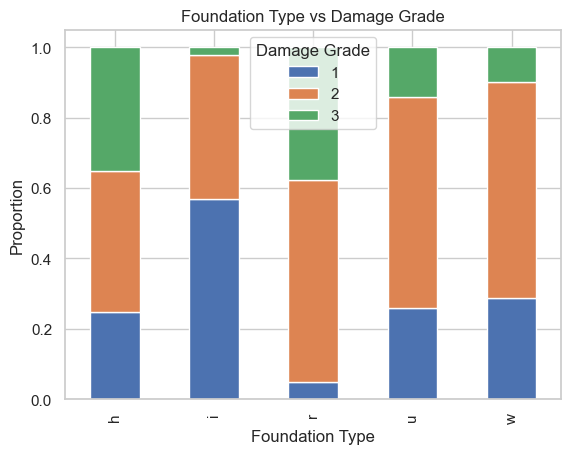

In [18]:
cross_tab = pd.crosstab(
    train_values.foundation_type,
    train_labels.damage_grade,
    normalize="index"
)

plt.figure()
cross_tab.plot(kind="bar", stacked=True)
plt.title("Foundation Type vs Damage Grade")
plt.xlabel("Foundation Type")
plt.ylabel("Proportion")
plt.legend(title="Damage Grade")
plt.show()

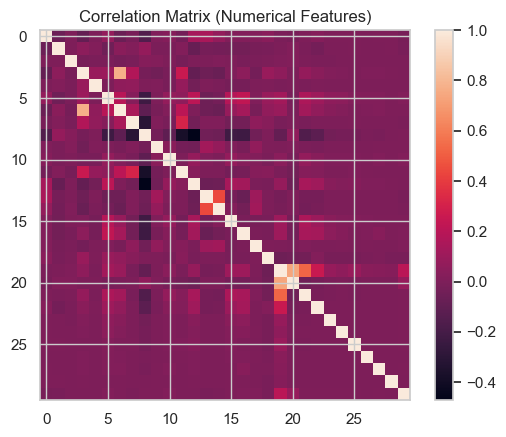

Average absolute correlation: 0.04


In [22]:
import numpy as np

numerical = train_values.select_dtypes(include=np.number)
correlation = numerical.corr()

plt.figure()
plt.imshow(correlation)
plt.title("Correlation Matrix (Numerical Features)")
plt.colorbar()
plt.show()

corr_matrix = numerical.corr()

# Remove diagonal (self-correlation)
mask = ~np.eye(corr_matrix.shape[0], dtype=bool)

avg_corr = np.mean(np.abs(corr_matrix.values[mask]))

print("Average absolute correlation:", round(avg_corr, 3))

In [23]:
train_values.shape
train_values.dtypes.value_counts()

int64    30
str       8
Name: count, dtype: int64